In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
from scipy.signal import butter, filtfilt,welch
from sklearn.linear_model import LinearRegression
data = pd.read_csv('data/emg_data_600_combined.csv')

Fs = 200 
nyq = Fs / 2

# Band-pass filter (20–90 Hz)
def bandpass(signal, low=20, high=90, fs=200, order=4):
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

# Apply to all channels
filtered = data.apply(lambda ch: bandpass(ch), axis=0)

# Segment into windows (e.g. 200ms to 40 samples)
win_size = 40
step = 20
features = []

fatigue_features = {ch: {"RMS": [], "MDF": []} for ch in filtered.columns}

for start in range(0, len(filtered) - win_size, step):
    window = filtered.iloc[start:start+win_size]
    for i, col in enumerate(window.columns):
        ch_data = window[col].values
        
        # Time-domain feature
        rms = np.sqrt(np.mean(ch_data**2))
        
        # Frequency-domain feature
        f, Pxx = welch(ch_data, fs=Fs, nperseg=win_size)
        cumsum = np.cumsum(Pxx)
        mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]
        
        fatigue_features[col]["RMS"].append(rms)
        fatigue_features[col]["MDF"].append(mdf)


In [10]:
print(fatigue_features.keys())

dict_keys(['Fatigue_Value'])


In [11]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

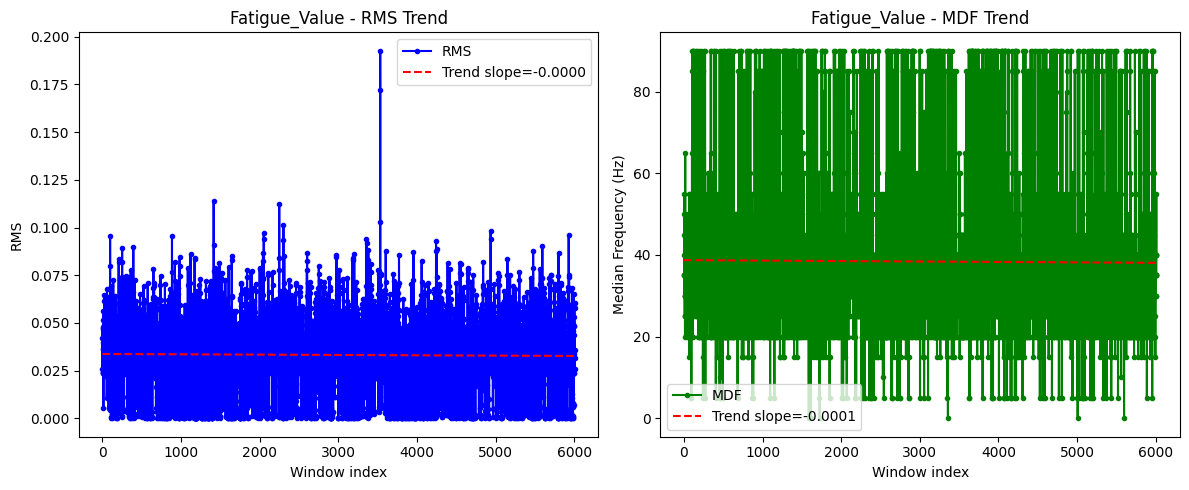

In [12]:
# Loop through all channels in the dataset
for channel in filtered.columns:   # e.g., "Ch1", "Ch2", ...
    # RMS
    time_windows = np.arange(len(fatigue_features[channel]["RMS"]))
    X = time_windows.reshape(-1, 1)
    y_rms = np.array(fatigue_features[channel]["RMS"])   
    model_rms = LinearRegression().fit(X, y_rms)
    trend_rms = model_rms.predict(X)
    # MDF
    y_mdf = np.array(fatigue_features[channel]["MDF"])
    model_mdf = LinearRegression().fit(X, y_mdf)
    trend_mdf = model_mdf.predict(X)

    # Plot RMS and MDF for this channel
    plt.figure(figsize=(12, 5))

    # RMS Plot
    plt.subplot(1, 2, 1)
    plt.plot(time_windows, y_rms, 'b.-', label="RMS")
    plt.plot(time_windows, trend_rms, 'r--', label=f"Trend slope={model_rms.coef_[0]:.4f}")
    plt.xlabel("Window index")
    plt.ylabel("RMS")
    plt.title(f"{channel} - RMS Trend")
    plt.legend()

    # MDF Plot
    plt.subplot(1, 2, 2)
    plt.plot(time_windows, y_mdf, 'g.-', label="MDF")
    plt.plot(time_windows, trend_mdf, 'r--', label=f"Trend slope={model_mdf.coef_[0]:.4f}")
    plt.xlabel("Window index")
    plt.ylabel("Median Frequency (Hz)")
    plt.title(f"{channel} - MDF Trend")
    plt.legend()

    plt.tight_layout()
    plt.show()

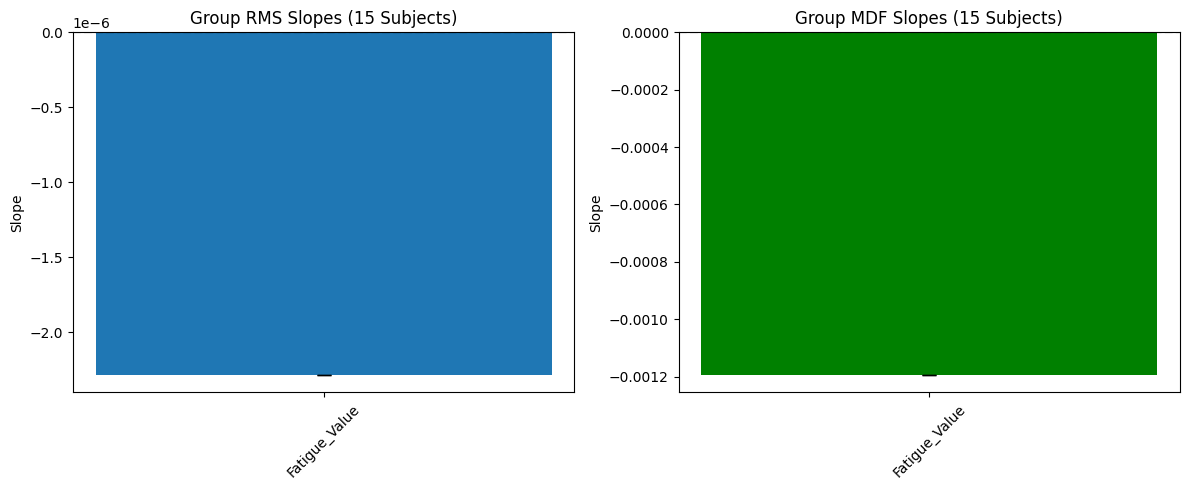

In [ ]:
subjects = [f"data/emg_data_600_combined.csv"]  # file names
Fs = 200

# Store slopes
slopes_rms = {ch: [] for ch in filtered.columns}
slopes_mdf = {ch: [] for ch in filtered.columns}

for subj_file in subjects:
    data = pd.read_csv(subj_file)
    filtered = data.apply(lambda ch: bandpass(ch), axis=0)

    # Windowing
    win_size = 200  # 2s
    step = 200 
    fatigue_features = {ch: {"RMS": [], "MDF": []} for ch in filtered.columns}

    for start in range(0, len(filtered) - win_size, step):
        window = filtered.iloc[start:start+win_size]
        for col in window.columns:
            ch_data = window[col].values
            rms = np.sqrt(np.mean(ch_data**2))

            f, Pxx = welch(ch_data, fs=Fs, nperseg=win_size)
            cumsum = np.cumsum(Pxx)
            mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]

            fatigue_features[col]["RMS"].append(rms)
            fatigue_features[col]["MDF"].append(mdf)

    # Compute slopes per channel for this subject
    for ch in filtered.columns:
        time_windows = np.arange(len(fatigue_features[ch]["RMS"])).reshape(-1, 1)

        # RMS slope
        y_rms = np.array(fatigue_features[ch]["RMS"])
        slope_rms = LinearRegression().fit(time_windows, y_rms).coef_[0]
        slopes_rms[ch].append(slope_rms)

        # MDF slope
        y_mdf = np.array(fatigue_features[ch]["MDF"])
        slope_mdf = LinearRegression().fit(time_windows, y_mdf).coef_[0]
        slopes_mdf[ch].append(slope_mdf)

# Convert to group averages
mean_rms = {ch: np.mean(slopes_rms[ch]) for ch in slopes_rms}
std_rms = {ch: np.std(slopes_rms[ch]) for ch in slopes_rms}

mean_mdf = {ch: np.mean(slopes_mdf[ch]) for ch in slopes_mdf}
std_mdf = {ch: np.std(slopes_mdf[ch]) for ch in slopes_mdf}

# Plot group summary
channels = list(filtered.columns)

plt.figure(figsize=(12, 5))

# RMS slopes
plt.subplot(1, 2, 1)
plt.bar(channels, [mean_rms[ch] for ch in channels], yerr=[std_rms[ch] for ch in channels], capsize=5)
plt.axhline(0, color='k', linestyle='--')
plt.title("Group RMS Slopes (15 Subjects)")
plt.ylabel("Slope")
plt.xticks(rotation=45)

# MDF slopes
plt.subplot(1, 2, 2)
plt.bar(channels, [mean_mdf[ch] for ch in channels], yerr=[std_mdf[ch] for ch in channels], capsize=5, color='g')
plt.axhline(0, color='k', linestyle='--')
plt.title("Group MDF Slopes (15 Subjects)")
plt.ylabel("Slope")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.signal import butter, filtfilt, welch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Fs = 200  # Sampling frequency
nyq = Fs / 2


# 1. Preprocessing functions

def bandpass(signal, low=20, high=90, fs=200, order=4):
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def extract_features(window, fs=200):
    """Extract RMS, MAV, Variance, Median Frequency per channel"""
    feats = []
    for ch in window.T:  # loop over channels
        rms = np.sqrt(np.mean(ch**2))
        mav = np.mean(np.abs(ch))
        var = np.var(ch)

        # Median frequency
        f, Pxx = welch(ch, fs=fs, nperseg=len(ch))
        cumsum = np.cumsum(Pxx)
        mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]

        feats.extend([rms, mav, var, mdf])
    return feats


# 2. Build dataset across 15 subjects

subjects = [f"data/emg_data_600_combined.csv"]   # file names
win_size = 200   # 2s windows (200 Hz × 2s)
step = 100       # 50% overlap

X, y = [], []

for subj_file in subjects:
    data = pd.read_csv(subj_file)   # shape: (24000, 8)
    filtered = data.apply(lambda ch: bandpass(ch), axis=0)

    # Non-fatigue = first 30s, Fatigue = last 30s
    n_samples = len(filtered)
    first_part = int(30 * Fs)  # 30 sec
    last_part = n_samples - first_part

    for start in range(0, first_part - win_size, step):
        window = filtered.iloc[start:start+win_size].values
        feats = extract_features(window, Fs)
        X.append(feats)
        y.append(0)  # Non-fatigue

    for start in range(last_part, n_samples - win_size, step):
        window = filtered.iloc[start:start+win_size].values
        feats = extract_features(window, Fs)
        X.append(feats)
        y.append(1)  # Fatigue

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


# Train/Test Split + Classifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Non-Fatigue", "Fatigue"]))


# Predict on a new window


# new_window = np.random.randn(400, 8) 
# new_feats = extract_features(new_window, Fs)
# prediction = clf.predict([new_feats])
# print("Predicted:", "Fatigue" if prediction[0]==1 else "Non-Fatigue")

Feature matrix shape: (116, 4)
Labels shape: (116,)
Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

 Non-Fatigue       0.62      0.57      0.59        14
     Fatigue       0.45      0.50      0.48        10

    accuracy                           0.54        24
   macro avg       0.53      0.54      0.53        24
weighted avg       0.55      0.54      0.54        24



In [ ]:
Fs = 200          # Sampling frequency (Hz)
window_size = 200 # 2 seconds change it to 200 later
step = 100        # 50% overlap
n_channels = 1


#Load sEMG data

data = pd.read_csv("data/emg_data_600_combined.csv")  # shape = (24000, 8)


#Feature extraction

time_windows = []
rms_matrix = []  # (num_windows × 8)
mdf_matrix = []







In [19]:
#Compute slope per channel
for start in range(0, len(data) - window_size, step):
    window = data.iloc[start:start+window_size].values
    rms_row, mdf_row = [], []

    for ch in window.T:
        rms = np.sqrt(np.mean(ch**2))
        f, Pxx = welch(ch, fs=Fs, nperseg=len(ch))
        cumsum = np.cumsum(Pxx)
        mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]
        rms_row.append(rms)
        mdf_row.append(mdf)

    rms_matrix.append(rms_row)
    mdf_matrix.append(mdf_row)
    time_windows.append(start / Fs)

rms_matrix = np.array(rms_matrix)
mdf_matrix = np.array(mdf_matrix)
time_windows = np.array(time_windows)



Channel-wise fatigue analysis:
Ch1: RMS slope=0.000230, MDF slope=-0.000014 → Not fatigued

Overall Fatigue Score: 0.0%
 Muscle not fatigued yet.


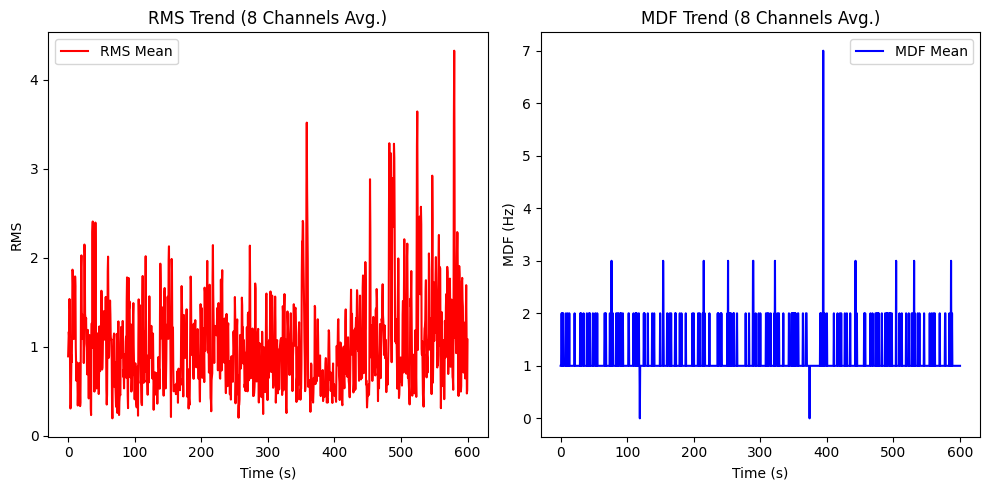

In [20]:
rms_slopes, mdf_slopes = [], []

for ch in range(n_channels):
    t = np.arange(len(rms_matrix)).reshape(-1, 1)
    rms_slope = LinearRegression().fit(t, rms_matrix[:, ch]).coef_[0]
    mdf_slope = LinearRegression().fit(t, mdf_matrix[:, ch]).coef_[0]
    rms_slopes.append(rms_slope)
    mdf_slopes.append(mdf_slope)


# 4. Fatigue decision per channel

rms_threshold = 1e-5
mdf_threshold = -1e-4
fatigued_channels = 0

print("\nChannel-wise fatigue analysis:")
for i, (r_s, m_s) in enumerate(zip(rms_slopes, mdf_slopes)):
    is_fatigued = (r_s > rms_threshold and m_s < mdf_threshold)
    status = "Fatigued" if is_fatigued else "Not fatigued"
    if is_fatigued:
        fatigued_channels += 1
    print(f"Ch{i+1}: RMS slope={r_s:.6f}, MDF slope={m_s:.6f} → {status}")

fatigue_score = (fatigued_channels / n_channels) * 100
print(f"\nOverall Fatigue Score: {fatigue_score:.1f}%")

if fatigue_score >= 50:
    print(" Muscle is likely fatigued (majority of channels).")
else:
    print(" Muscle not fatigued yet.")

#  Visualization

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(time_windows, np.mean(rms_matrix, axis=1), 'r', label='RMS Mean')
plt.title("RMS Trend (8 Channels Avg.)")
plt.xlabel("Time (s)")
plt.ylabel("RMS")
plt.legend()

plt.subplot(1,2,2)
plt.plot(time_windows, np.mean(mdf_matrix, axis=1), 'b', label='MDF Mean')
plt.title("MDF Trend (8 Channels Avg.)")
plt.xlabel("Time (s)")
plt.ylabel("MDF (Hz)")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# new_input = np.array([-8.0,12.0,-26.0,18.0,6.0,-10.0,8.0,40.0])

# # Compare with average non-fatigued and fatigued trends
# rms_mean_fatigue = np.mean([r for r in rms_slopes if r > 0])
# mdf_mean_fatigue = np.mean([m for m in mdf_slopes if m < 0])

# # if most channels are trending like fatigue
# fatigue_indicator = 0
# if rms_mean_fatigue > rms_threshold and mdf_mean_fatigue < mdf_threshold:
#     fatigue_indicator = 1

# print("\n--- Instant 8-Channel Prediction ---")
# print("Input RMS values:", new_input)
# print(f"Estimated fatigue trend → {'Fatigued' if fatigue_indicator else 'Not fatigued'}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.signal import welch
import matplotlib.pyplot as plt

fs = 200          # Sampling frequency




df = pd.read_csv(f"data/emg_data_600_combined.csv") 




In [23]:
def compute_rms(signal):
    """Compute RMS of a 1D array."""
    return np.sqrt(np.mean(signal ** 2))

def compute_mdf(signal, fs):
    """Compute Median Frequency using Welch's method."""
    f, Pxx = welch(signal, fs=fs, nperseg=fs)
    cumsum = np.cumsum(Pxx)
    cutoff = cumsum[-1] / 2
    mdf = f[np.where(cumsum >= cutoff)[0][0]]
    return mdf

def compute_features(df, fs=200, window_sec=1):
    """Compute RMS and MDF per window for each channel."""
    win_size = fs * window_sec
    n_windows = len(df) // win_size
    rms_values, mdf_values = {}, {}
    
    for ch in df.columns:
        rms_list, mdf_list = [], []
        for w in range(n_windows):
            segment = df[ch].iloc[w*win_size:(w+1)*win_size].values
            rms_list.append(compute_rms(segment))
            mdf_list.append(compute_mdf(segment, fs))
        rms_values[ch] = rms_list
        mdf_values[ch] = mdf_list

    return pd.DataFrame(rms_values), pd.DataFrame(mdf_values)
#  Extract RMS & MDF trends

rms_df, mdf_df = compute_features(df, fs=fs, window_sec=1)
time_windows = np.arange(len(rms_df))

rms_slopes, mdf_slopes = {}, {}
for ch in df.columns:
    X = time_windows.reshape(-1, 1)
    rms_slope = LinearRegression().fit(X, rms_df[ch]).coef_[0]
    mdf_slope = LinearRegression().fit(X, mdf_df[ch]).coef_[0]
    rms_slopes[ch] = rms_slope
    mdf_slopes[ch] = mdf_slope


#  Fatigue detection logic

def detect_fatigue(new_values, rms_slopes, mdf_slopes, rms_df, mdf_df):
    """
    new_values: dict like {'Ch1': [samples...], 'Ch2': [...], ...}
    returns: fatigue status per channel
    """
    results = {}
    for ch in rms_slopes.keys():
        # compute current RMS & MDF of new signal
        rms_val = compute_rms(np.array(new_values[ch]))
        mdf_val = compute_mdf(np.array(new_values[ch]), fs)

        mean_rms = np.mean(rms_df[ch])
        mean_mdf = np.mean(mdf_df[ch])

        # fatigue if RMS ↑ and MDF ↓
        if rms_slopes[ch] > 0 and mdf_slopes[ch] < 0 and rms_val > mean_rms and mdf_val < mean_mdf:
            results[ch] = "Fatigued"
        else:
            results[ch] = "Non-Fatigued"
    return results




In [24]:
column_set = {column_name: df[column_name].to_numpy() for column_name in df.columns}
print(column_set)

{'Fatigue_Value': array([-0.8635, -0.8624, -0.8613, ...,  2.7264,  2.9583,  2.9551],
      shape=(120205,))}


In [33]:
# Example: Predict fatigue for a new 8-channel input

# Simulate a new 1-second window (user input)
new_input = {}

column_array = df['Fatigue_Value'].to_numpy()
new_input['Fatigue_Value'] = column_array[21000:21200]
    #new_input[f'Ch{i}'] = column_array[x:x+200] as only 200 samples are taken, which compares to 1s
# Detect fatigue
status = detect_fatigue(new_input, rms_slopes, mdf_slopes, rms_df, mdf_df)


#  Show results

print("\n=== Channel-wise Fatigue Status ===")
for ch, st in status.items():
    print(f"{ch}: {st}")


=== Channel-wise Fatigue Status ===
Fatigue_Value: Non-Fatigued


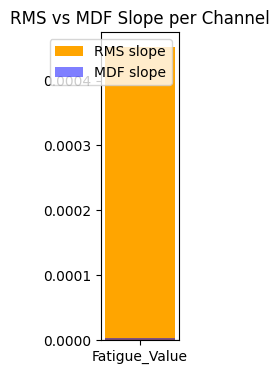

In [34]:
# Optional: plot RMS & MDF slope comparison
plt.figure(figsize=(1,4))
plt.bar(range(1), list(rms_slopes.values()), color='orange', label='RMS slope')
plt.bar(range(1), list(mdf_slopes.values()), color='blue', alpha=0.5, label='MDF slope')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(range(1), list(rms_slopes.keys()))
plt.title("RMS vs MDF Slope per Channel")
plt.legend()
plt.show()